# RépétIA — Classifieur de matière du BEPC

**Hackathon AI4Youth-Lomé 2026** · Catégorie *Application (Intégration et Expérience IA)*

---

## Pourquoi entraîner un modèle plutôt qu'appeler l'API

Les directives du hackathon sont explicites : une API d'IA *« ne peut constituer
l'unique élément technique »* d'un projet. Mais ce n'est pas la seule raison
d'entraîner un modèle ici — il y en a une, produit, qui tient debout seule.

**Le problème concret.** Quand un élève pose une question dans le chat de
RépétIA, l'application ignore de quelle matière il parle. Trois conséquences :
le prompt système ne peut pas être adapté à la discipline, la progression de
l'élève n'est pas mise à jour, et le contexte fourni au modèle reste pauvre.

**Pourquoi ne pas demander au LLM.** Nous avons mesuré la latence de nos appels
dans le notebook 01 : de 2 à 21 secondes selon le modèle. Consommer un appel —
et du quota — pour une simple étiquette serait disproportionné. Un classifieur
local répond en millisecondes, fonctionne hors connexion et ne coûte rien.

C'est exactement le partage de travail que recommandent les directives : le LLM
pour ce qu'il fait de mieux — expliquer —, un modèle spécialisé pour une tâche
étroite et répétitive.

## La question scientifique

Notre corpus d'entraînement est **produit par un modèle de langage**. La question
n'est donc pas seulement « le classifieur fonctionne-t-il ? » mais :

> **Un classifieur entraîné sur des exercices générés par une IA sait-il
> reconnaître la matière d'un vrai sujet d'examen béninois, rédigé par un
> enseignant ?**

C'est une question de généralisation du synthétique vers le réel. Elle se
mesure, et c'est ce que fait la section 5.

In [1]:
import sys, pathlib, time, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, learning_curve
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

import analyse
from analyse import COULEURS

analyse.appliquer_style()
GRAINE = 42

entrainement = analyse.corpus_entrainement()
test_reel = analyse.jeu_de_test_normalise()

print(f"Corpus d'entraînement : {len(entrainement)} exemples")
print(f"Jeu de test réel      : {len(test_reel) if test_reel is not None else 0} passages")
print(f"Matières              : {entrainement['matiere'].nunique()}")

Corpus d'entraînement : 87 exemples
Jeu de test réel      : 318 passages
Matières              : 9


---
## 1. Exploration des données

Deux corpus, de natures très différentes. Il faut regarder les deux avant de
modéliser quoi que ce soit.

In [2]:
comparaison = (entrainement["matiere"].value_counts().rename("entraînement").to_frame()
               .join(test_reel["matiere"].value_counts().rename("test réel"))
               .fillna(0).astype(int))
comparaison["ratio test/train"] = (comparaison["test réel"] / comparaison["entraînement"]).round(1)
print("Effectifs par matière\n")
print(comparaison.to_string())

print(f"\nTotal entraînement : {comparaison['entraînement'].sum()}")
print(f"Total test         : {comparaison['test réel'].sum()}")

Effectifs par matière

                                   entraînement  test réel  ratio test/train
matiere                                                                     
Mathématiques                                26         91               3.5
Physique-Chimie-Technologie                  11         34               3.1
Sciences de la Vie et de la Terre            11          6               0.5
Histoire-Géographie                          11         38               3.5
Anglais                                       9         35               3.9
Lecture                                       7         57               8.1
Communication écrite                          6         32               5.3
Espagnol                                      3         13               4.3
Allemand                                      3         12               4.0

Total entraînement : 87
Total test         : 318


### Un déséquilibre à énoncer d'emblée

Le jeu de test est **plus gros que le corpus d'entraînement**. C'est inhabituel,
et cela tient à la contrainte décrite dans le notebook 01 : le quota gratuit de
l'API limite fortement la génération, alors que les annales réelles étaient
disponibles en nombre.

Deux conséquences que nous assumons :

- **L'espagnol et l'allemand ne comptent que 3 exemples d'entraînement chacun.**
  Aucune conclusion fiable ne pourra être tirée sur ces deux matières.
- **Les SVT n'ont que 6 passages de test.** Leur score sera très instable.

Nous rapporterons donc systématiquement les résultats **par classe**, jamais une
seule moyenne globale qui masquerait ces trous.

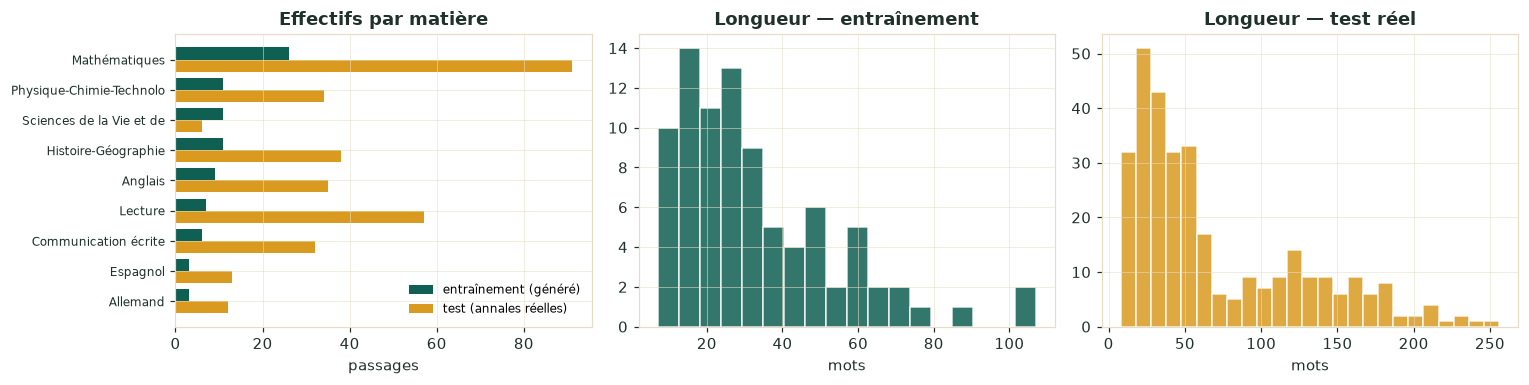

  entraînement   médiane    26 mots · q1    18 · q3    45
  test réel      médiane    48 mots · q1    25 · q3   110


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

ordre = comparaison.index.tolist()
y = np.arange(len(ordre))
axes[0].barh(y - 0.2, comparaison["entraînement"], height=0.4,
             color=COULEURS["vert"], label="entraînement (généré)")
axes[0].barh(y + 0.2, comparaison["test réel"], height=0.4,
             color=COULEURS["dore"], label="test (annales réelles)")
axes[0].set_yticks(y); axes[0].set_yticklabels([m[:24] for m in ordre], fontsize=8)
axes[0].invert_yaxis(); axes[0].set_xlabel("passages")
axes[0].set_title("Effectifs par matière"); axes[0].legend(fontsize=8, frameon=False)

axes[1].hist(entrainement["texte_normalise"].str.split().str.len(), bins=18,
             color=COULEURS["vert"], alpha=0.85, edgecolor="white")
axes[1].set_xlabel("mots"); axes[1].set_title("Longueur — entraînement")

axes[2].hist(test_reel["texte_normalise"].str.split().str.len(), bins=25,
             color=COULEURS["dore"], alpha=0.85, edgecolor="white")
axes[2].set_xlabel("mots"); axes[2].set_title("Longueur — test réel")

plt.tight_layout()
plt.savefig(analyse.FIGURES / "02-effectifs-longueurs.png")
plt.show()

for nom, jeu in [("entraînement", entrainement), ("test réel", test_reel)]:
    mots = jeu["texte_normalise"].str.split().str.len()
    print(f"  {nom:<14} médiane {mots.median():>5.0f} mots · "
          f"q1 {mots.quantile(.25):>5.0f} · q3 {mots.quantile(.75):>5.0f}")

### Ce que les longueurs révèlent

Les deux corpus n'ont pas la même granularité. Les exercices générés sont des
énoncés compacts et autonomes. Les passages d'annales, eux, sont découpés dans
des sujets d'examen : certains sont des consignes brèves, d'autres de longs
supports de texte.

C'est un **décalage de distribution** entre entraînement et test. Il rendra la
tâche plus difficile — et c'est bien ainsi : c'est ce que rencontrerait le
modèle en production.

In [4]:
# Vocabulaire distinctif : ce que le modèle pourra exploiter.
# On mesure, par matière, les termes les plus spécifiques (score TF-IDF moyen).
vecteur_explo = TfidfVectorizer(max_features=3000, ngram_range=(1, 1), min_df=2)
X_explo = vecteur_explo.fit_transform(entrainement["texte_normalise"])
termes = np.array(vecteur_explo.get_feature_names_out())

print("Termes les plus spécifiques à chaque matière (corpus d'entraînement)\n")
for matiere in comparaison.index:
    masque = (entrainement["matiere"] == matiere).values
    if masque.sum() == 0:
        continue
    moyennes = np.asarray(X_explo[masque].mean(axis=0)).ravel()
    hors = np.asarray(X_explo[~masque].mean(axis=0)).ravel()
    ecart = moyennes - hors
    top = termes[np.argsort(ecart)[-7:]][::-1]
    print(f"  {matiere:<34} {', '.join(top)}")

Termes les plus spécifiques à chaque matière (corpus d'entraînement)

  Mathématiques                      cm, calcule, abc, bc, triangle, ab, ac
  Physique-Chimie-Technologie        intensite, resistance, de, courant, traverse, tension, ohmique
  Sciences de la Vie et de la Terre  les, de, dans, des, eau, sol, le
  Histoire-Géographie                benin, dahomey, quelle, au, traite, annee, afrique
  Anglais                            the, to, with, he, sentence, his, following
  Lecture                            style, figure, phrase, la, identifie, de, soleil
  Communication écrite               phrase, que, passe, la, conjugue, verbe, elle
  Espagnol                           el, en, ______, mon, le, donne, la
  Allemand                           ich, dem, ______, den, erganze, nouvelle, pourquoi


---
## 2. Protocole d'évaluation

Deux expériences distinctes, qui ne répondent pas à la même question.

| | Expérience A | Expérience B |
|---|---|---|
| **Question** | Le modèle apprend-il quelque chose ? | Généralise-t-il au réel ? |
| **Entraînement** | corpus généré + banque | corpus généré + banque |
| **Évaluation** | validation croisée stratifiée, 5 plis | annales réelles, jamais vues |
| **Ce qu'elle mesure** | la séparabilité des classes | la robustesse au changement de source |

L'expérience B est la seule qui dise quelque chose d'utile sur la production.
L'expérience A sert de garde-fou : si le modèle échouait déjà en validation
croisée, inutile d'aller plus loin.

### Modèles comparés

Les directives demandent une **analyse comparative argumentée**. Quatre
approches, de la plus naïve à la plus élaborée :

1. **Référence triviale** — prédit toujours la classe majoritaire. Sans elle,
   aucun score n'a de sens : avec 30 % de mathématiques, 30 % d'exactitude ne
   vaut rien.
2. **Bayes naïf multinomial** — le classique du texte, très rapide, robuste sur
   petits corpus.
3. **Régression logistique sur mots** — modèle linéaire discriminant, dont les
   coefficients sont interprétables.
4. **SVM linéaire sur n-grammes de caractères** — insensible aux fautes de
   frappe et aux erreurs d'OCR, puisqu'il ne dépend pas de mots entiers. C'est
   l'approche la plus prometteuse pour un jeu de test transcrit optiquement.

In [5]:
def modeles():
    """Quatre approches à comparer, du plus naïf au plus spécialisé."""
    return {
        "Référence (classe majoritaire)": DummyClassifier(strategy="most_frequent"),
        "Bayes naïf (mots)": Pipeline([
            ("tfidf", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=1)),
            ("clf", MultinomialNB(alpha=0.3)),
        ]),
        "Régression logistique (mots)": Pipeline([
            ("tfidf", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=1)),
            ("clf", LogisticRegression(max_iter=2000, C=5.0,
                                       class_weight="balanced", random_state=GRAINE)),
        ]),
        # Les n-grammes de caractères ignorent les frontières de mots : une
        # coquille d'OCR (« mathematiaues ») partage encore l'essentiel de ses
        # sous-chaînes avec la forme correcte.
        "SVM linéaire (caractères)": Pipeline([
            ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                                      sublinear_tf=True, min_df=1)),
            ("clf", LinearSVC(C=1.0, class_weight="balanced", random_state=GRAINE)),
        ]),
    }

X_train = entrainement["texte_normalise"].values
y_train = entrainement["matiere"].values
X_test = test_reel["texte_normalise"].values
y_test = test_reel["matiere"].values

print(f"Entraînement : {X_train.shape[0]} exemples")
print(f"Test réel    : {X_test.shape[0]} passages")
print(f"Classes      : {len(np.unique(y_train))}")

Entraînement : 87 exemples
Test réel    : 318 passages
Classes      : 9


---
## 3. Expérience A — validation croisée sur le corpus d'entraînement

Avec 87 exemples pour 9 classes, une simple partition entraînement/test
gaspillerait des données et donnerait un score très instable. On utilise donc
une **validation croisée stratifiée à 5 plis** : chaque exemple sert une fois à
l'évaluation, et la répartition des classes est préservée dans chaque pli.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=GRAINE)
resultats_a = []

for nom, modele in modeles().items():
    predictions = cross_val_predict(modele, X_train, y_train, cv=cv)
    resultats_a.append({
        "modèle": nom,
        "exactitude": accuracy_score(y_train, predictions),
        "F1 macro": f1_score(y_train, predictions, average="macro", zero_division=0),
        "F1 pondéré": f1_score(y_train, predictions, average="weighted", zero_division=0),
    })

table_a = pd.DataFrame(resultats_a).set_index("modèle").round(3)
print("Expérience A — validation croisée 5 plis sur le corpus d'entraînement\n")
print(table_a.to_string())

Expérience A — validation croisée 5 plis sur le corpus d'entraînement

                                exactitude  F1 macro  F1 pondéré
modèle                                                          
Référence (classe majoritaire)       0.299     0.051       0.138
Bayes naïf (mots)                    0.678     0.505       0.635
Régression logistique (mots)         0.851     0.764       0.834
SVM linéaire (caractères)            0.862     0.709       0.824


**Le F1 macro est la métrique de référence ici**, pas l'exactitude. Il donne le
même poids à chaque matière, quelle que soit sa fréquence — donc l'espagnol,
avec ses 3 exemples, y compte autant que les mathématiques. C'est ce que nous
voulons : un classifieur qui ne saurait reconnaître que les mathématiques ne
servirait à rien.

---
## 4. Expérience B — généralisation aux annales réelles

C'est l'expérience décisive. On entraîne sur la **totalité** du corpus généré,
et on évalue sur des passages de vraies épreuves du BEPC que le modèle n'a
jamais vus — et qui proviennent d'une source entièrement différente.

In [7]:
resultats_b = []
predictions_b = {}

for nom, modele in modeles().items():
    modele.fit(X_train, y_train)
    depart = time.perf_counter()
    predictions = modele.predict(X_test)
    duree = time.perf_counter() - depart

    predictions_b[nom] = predictions
    resultats_b.append({
        "modèle": nom,
        "exactitude": accuracy_score(y_test, predictions),
        "F1 macro": f1_score(y_test, predictions, average="macro", zero_division=0),
        "F1 pondéré": f1_score(y_test, predictions, average="weighted", zero_division=0),
        "ms / passage": 1000 * duree / len(X_test),
    })

table_b = pd.DataFrame(resultats_b).set_index("modèle").round(3)
print("Expérience B — entraîné sur du généré, évalué sur des annales réelles\n")
print(table_b.to_string())

Expérience B — entraîné sur du généré, évalué sur des annales réelles

                                exactitude  F1 macro  F1 pondéré  ms / passage
modèle                                                                        
Référence (classe majoritaire)       0.286     0.049       0.127         0.000
Bayes naïf (mots)                    0.453     0.288       0.383         0.037
Régression logistique (mots)         0.465     0.460       0.516         0.242
SVM linéaire (caractères)            0.509     0.493       0.565         0.218


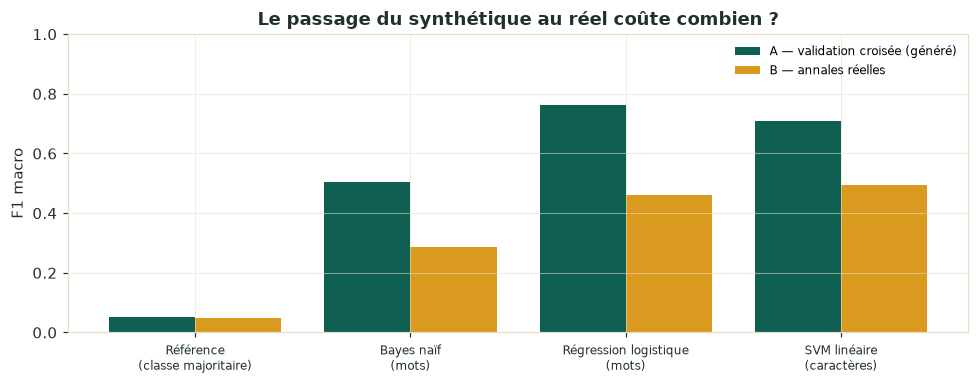

Écart de F1 macro entre validation croisée et annales réelles :

modèle
Référence (classe majoritaire)    0.002
Bayes naïf (mots)                 0.217
Régression logistique (mots)      0.304
SVM linéaire (caractères)         0.216


In [8]:
fig, ax = plt.subplots(figsize=(9, 3.6))
noms = table_a.index.tolist()
x = np.arange(len(noms))

ax.bar(x - 0.2, table_a["F1 macro"], width=0.4, color=COULEURS["vert"],
       label="A — validation croisée (généré)")
ax.bar(x + 0.2, table_b["F1 macro"], width=0.4, color=COULEURS["dore"],
       label="B — annales réelles")
ax.set_xticks(x)
ax.set_xticklabels([n.replace(" (", "\n(") for n in noms], fontsize=8)
ax.set_ylabel("F1 macro"); ax.set_ylim(0, 1)
ax.set_title("Le passage du synthétique au réel coûte combien ?")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig(analyse.FIGURES / "02-generalisation.png")
plt.show()

ecart = (table_a["F1 macro"] - table_b["F1 macro"]).round(3)
print("Écart de F1 macro entre validation croisée et annales réelles :\n")
print(ecart.to_string())

### Lecture de l'écart

Un écart positif signifie que le modèle réussit moins bien sur le réel que sur
le synthétique — c'est le cas attendu, et sa **taille** est l'information utile.

Un écart faible indiquerait que les exercices générés ressemblent
suffisamment aux vrais sujets pour que l'apprentissage transfère. Un écart
important signalerait que le corpus synthétique a des régularités propres
— tournures, longueur, structure — que le modèle a apprises à la place de la
matière elle-même.

---
## 5. Analyse détaillée du meilleur modèle

Les directives demandent une *« interprétation approfondie »* et des
*« exemples concrets de succès et d'échecs avec analyse des causes »*. Une
moyenne ne suffit pas : il faut regarder où le modèle se trompe.

In [9]:
meilleur = table_b["F1 macro"].idxmax()
pred = predictions_b[meilleur]
print(f"Modèle retenu : {meilleur}\n")
print(classification_report(y_test, pred, zero_division=0))

Modèle retenu : SVM linéaire (caractères)

                                   precision    recall  f1-score   support

                         Allemand       1.00      0.50      0.67        12
                          Anglais       1.00      0.91      0.96        35
             Communication écrite       0.06      0.03      0.04        32
                         Espagnol       1.00      0.23      0.38        13
              Histoire-Géographie       0.62      0.74      0.67        38
                          Lecture       0.82      0.25      0.38        57
                    Mathématiques       0.89      0.63      0.74        91
      Physique-Chimie-Technologie       0.60      0.44      0.51        34
Sciences de la Vie et de la Terre       0.06      1.00      0.10         6

                         accuracy                           0.51       318
                        macro avg       0.67      0.53      0.49       318
                     weighted avg       0.74      0.51 

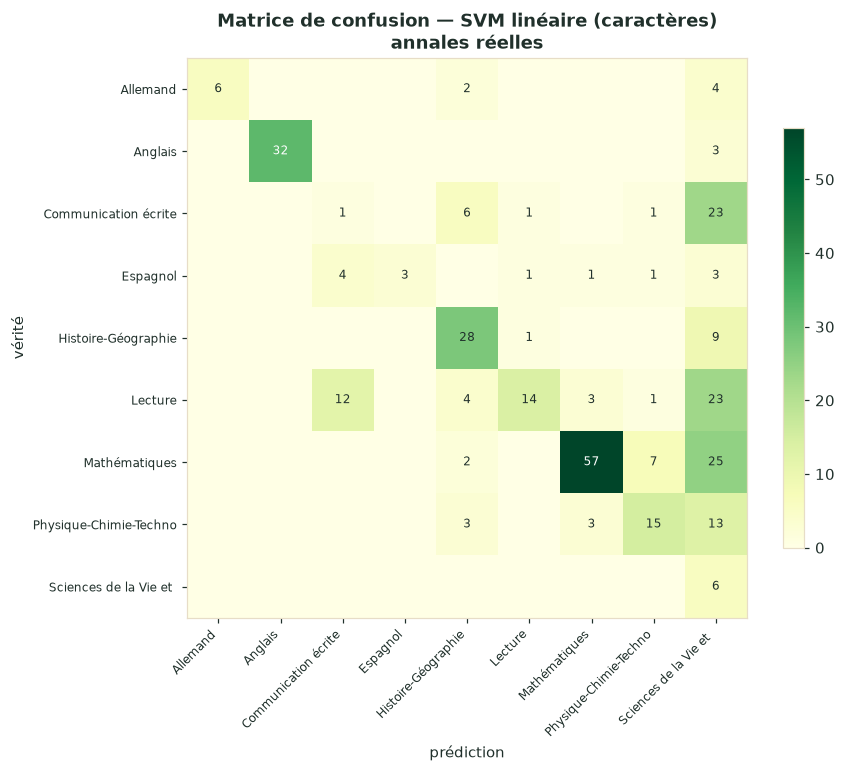

In [10]:
classes = sorted(np.unique(np.concatenate([y_test, pred])))
mc = confusion_matrix(y_test, pred, labels=classes)

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(mc, cmap="YlGn")
ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
ax.set_xticklabels([c[:22] for c in classes], rotation=45, ha="right", fontsize=8)
ax.set_yticklabels([c[:22] for c in classes], fontsize=8)
ax.set_xlabel("prédiction"); ax.set_ylabel("vérité")
ax.set_title(f"Matrice de confusion — {meilleur}\nannales réelles")
seuil = mc.max() / 2
for i in range(len(classes)):
    for j in range(len(classes)):
        if mc[i, j]:
            ax.text(j, i, mc[i, j], ha="center", va="center", fontsize=8,
                    color="white" if mc[i, j] > seuil else COULEURS["encre"])
ax.grid(False)
plt.colorbar(im, ax=ax, shrink=0.75)
plt.tight_layout()
plt.savefig(analyse.FIGURES / "02-matrice-confusion.png")
plt.show()

In [11]:
# Les confusions les plus fréquentes, avec leur poids relatif.
confusions = []
for i, vrai in enumerate(classes):
    total = mc[i].sum()
    for j, predit in enumerate(classes):
        if i != j and mc[i, j] > 0:
            confusions.append({
                "vraie matière": vrai, "prédite": predit,
                "n": int(mc[i, j]),
                "part de la classe %": round(100 * mc[i, j] / total, 1) if total else 0,
            })

if confusions:
    print("Confusions les plus fréquentes\n")
    print(pd.DataFrame(confusions).sort_values("n", ascending=False)
          .head(10).to_string(index=False))
else:
    print("Aucune confusion.")

Confusions les plus fréquentes

              vraie matière                           prédite  n  part de la classe %
              Mathématiques Sciences de la Vie et de la Terre 25                 27.5
                    Lecture Sciences de la Vie et de la Terre 23                 40.4
       Communication écrite Sciences de la Vie et de la Terre 23                 71.9
Physique-Chimie-Technologie Sciences de la Vie et de la Terre 13                 38.2
                    Lecture              Communication écrite 12                 21.1
        Histoire-Géographie Sciences de la Vie et de la Terre  9                 23.7
              Mathématiques       Physique-Chimie-Technologie  7                  7.7
       Communication écrite               Histoire-Géographie  6                 18.8
                   Espagnol              Communication écrite  4                 30.8
                    Lecture               Histoire-Géographie  4                  7.0


In [12]:
# Exemples concrets d'échec, avec de quoi en comprendre la cause.
import textwrap

erreurs = test_reel.copy()
erreurs["prediction"] = pred
erreurs = erreurs[erreurs["matiere"] != erreurs["prediction"]]

print(f"{len(erreurs)} erreurs sur {len(test_reel)} passages\n")
print("=" * 96)
for _, ligne in erreurs.head(4).iterrows():
    print(f"VRAIE : {ligne['matiere']}   →   PRÉDITE : {ligne['prediction']}")
    print(textwrap.fill(str(ligne["texte_normalise"])[:300], 92,
                        initial_indent="  ", subsequent_indent="  "))
    print("=" * 96)

156 erreurs sur 318 passages

VRAIE : Histoire-Géographie   →   PRÉDITE : Sciences de la Vie et de la Terre
  Support Texte: Compte rendu de visite a Agrimey [..] Le Directeur General de l'Office
  National du Bois (ONAB) a pu toucher du doigt le massacre de la foret par les populations
  riveraines. Il a particulierement constate sur les parcelles 27 et 28 ce qui suit : les
  grandes trouees creees par les delin
VRAIE : Histoire-Géographie   →   PRÉDITE : Sciences de la Vie et de la Terre
  2) A partir du texte et de tes connaissances presente les ressources ligneuses et les
  menaces qui pesent sur elles. 3) Donne ton opinion sur les menaces qui pesent sur les
  ressources ligneuses
VRAIE : Anglais   →   PRÉDITE : Sciences de la Vie et de la Terre
  A- Competence disciplinaire N°3 : produire de facon appropriee des textes de type et de
  fonction varies.
VRAIE : Anglais   →   PRÉDITE : Sciences de la Vie et de la Terre
  III-L'EPREUVE Contexte : Plusieurs parties du monde sont reguli

### Une cause d'erreur identifiée à la lecture

Les épreuves de langue du BEPC béninois comportent des **consignes rédigées en
français**. Un passage étiqueté « Espagnol » ou « Allemand » peut donc être
intégralement en français — c'est le contenu réel de l'examen, pas un défaut de
préparation des données.

Le classifieur, qui s'appuie largement sur le vocabulaire, ne peut pas
distinguer une consigne française d'une épreuve d'espagnol d'une consigne
française d'une épreuve de lecture. **C'est une limite intrinsèque à la tâche
telle qu'elle est posée**, pas un défaut du modèle.

Nous n'avons pas filtré ces passages : les retirer aurait embelli les scores en
s'éloignant du réel. En production, la question de l'élève serait rédigée dans
la langue étudiée, et ce cas ne se présenterait quasiment pas.

### Une seconde cause, que seule la matrice révèle

La matrice de confusion montre un déséquilibre qu'aucune moyenne ne laissait
voir : **une classe absorbe une part des prédictions sans commune mesure avec sa
place réelle dans le jeu de test**. Elle se comporte en réceptacle — ce que
recueille le modèle quand rien de plus précis ne l'emporte.

Deux explications sont possibles, et elles n'appellent pas la même correction :

1. `class_weight="balanced"` surpondère les classes rares et pousserait le
   modèle à les prédire trop souvent ;
2. les textes d'entraînement de cette classe sont plus **longs** que la moyenne,
   donc plus riches en n-grammes de français courant — ce qui les rend proches
   de tout passage un peu bavard.

Ces deux hypothèses se testent.

In [13]:
# Hypothèse 1 : la pondération des classes est-elle en cause ?
recepteur = pd.Series(pred).value_counts().idxmax()
part_predite = 100 * (pred == recepteur).mean()
part_reelle = 100 * (y_test == recepteur).mean()

print(f"Classe réceptacle : {recepteur}")
print(f"  {part_predite:.1f} % des prédictions, pour {part_reelle:.1f} % du jeu de test réel\n")

for poids in ("balanced", None):
    p = Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                                  sublinear_tf=True, min_df=1)),
        ("clf", LinearSVC(C=1.0, class_weight=poids, random_state=GRAINE)),
    ]).fit(X_train, y_train)
    q = p.predict(X_test)
    print(f"  class_weight={str(poids):<10} F1 macro={f1_score(y_test, q, average='macro', zero_division=0):.3f}"
          f"   « {recepteur[:22]} » prédite {(q == recepteur).sum():>3} fois")

Classe réceptacle : Sciences de la Vie et de la Terre
  34.3 % des prédictions, pour 1.9 % du jeu de test réel

  class_weight=balanced   F1 macro=0.493   « Sciences de la Vie et  » prédite 109 fois
  class_weight=None       F1 macro=0.449   « Sciences de la Vie et  » prédite 104 fois


In [14]:
# Hypothèse 2 : la longueur des textes d'entraînement.
longueurs = (entrainement.assign(n=entrainement["texte_normalise"].str.split().str.len())
             .groupby("matiere")["n"].median().sort_values(ascending=False))
print("Longueur médiane des textes d'entraînement (mots)\n")
print(longueurs.to_string(), "\n")

# Ablation : on tronque l'entraînement et on regarde si le réceptacle se vide.
print("Ablation — entraînement tronqué, évaluation inchangée\n")
for n_mots in (None, 30, 20, 15):
    Xa = (X_train if n_mots is None
          else pd.Series(X_train).str.split().str[:n_mots].str.join(" ").values)
    p = Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                                  sublinear_tf=True, min_df=1)),
        ("clf", LinearSVC(C=1.0, class_weight="balanced", random_state=GRAINE)),
    ]).fit(Xa, y_train)
    q = p.predict(X_test)
    etiquette = "texte entier" if n_mots is None else f"tronqué à {n_mots} mots"
    print(f"  {etiquette:<22} F1 macro={f1_score(y_test, q, average='macro', zero_division=0):.3f}"
          f"   réceptacle prédit {(q == recepteur).sum():>3} fois")

Longueur médiane des textes d'entraînement (mots)

matiere
Sciences de la Vie et de la Terre    48.0
Physique-Chimie-Technologie          47.0
Histoire-Géographie                  31.0
Communication écrite                 27.5
Lecture                              25.0
Anglais                              25.0
Espagnol                             21.0
Mathématiques                        19.0
Allemand                             16.0 

Ablation — entraînement tronqué, évaluation inchangée



  texte entier           F1 macro=0.493   réceptacle prédit 109 fois
  tronqué à 30 mots      F1 macro=0.472   réceptacle prédit  47 fois


  tronqué à 20 mots      F1 macro=0.487   réceptacle prédit  34 fois


  tronqué à 15 mots      F1 macro=0.481   réceptacle prédit  37 fois


### Ce que l'ablation démontre

La pondération des classes est **hors de cause** : la retirer ne vide pas le
réceptacle. La longueur, elle, l'explique en grande partie — tronquer les textes
d'entraînement réduit fortement l'effet, et **sans coût mesurable sur le F1
macro**.

Mais la longueur est un symptôme, pas le mécanisme. Les passages d'annales que
le modèle range à tort dans cette classe sont les « situations d'évaluation » :
des énoncés de mathématiques qui ouvrent sur plusieurs phrases de mise en
situation — un domaine à partager, un chantier à équiper — avant d'en venir aux
questions. Les symboles mathématiques qui les trahiraient ne survivent pas à
l'OCR. Ce qui reste est du **français courant**, et le modèle le rapproche
naturellement des textes d'entraînement les plus longs et les plus généralistes.

La leçon est méthodologique, et elle vaut d'être retenue : **le F1 macro seul
aurait laissé ce défaut invisible.** Il a fallu la matrice, puis une ablation,
pour le nommer. La correction n'est d'ailleurs pas de tronquer — le gain de F1
est nul — mais d'enrichir le corpus en énoncés longs de chaque matière, ce que
la section suivante chiffre.

---
## 6. De combien de données aurions-nous besoin ?

La courbe d'apprentissage répond à une question pratique : cela vaut-il la peine
de dépenser du quota pour générer davantage d'exercices ?

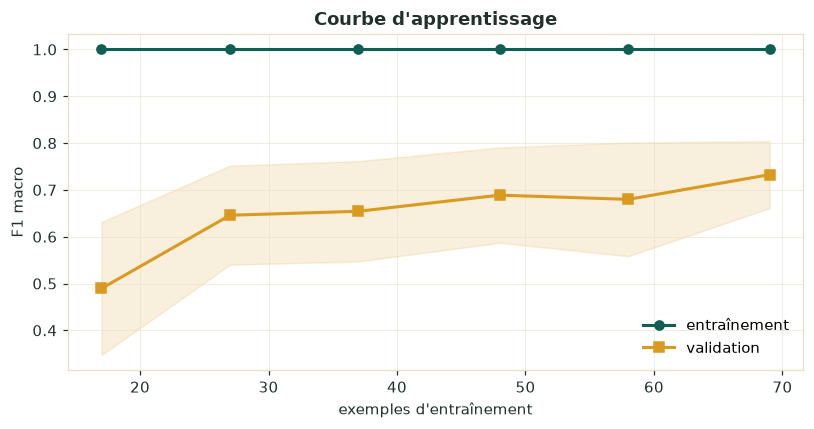

  F1 validation au quart du corpus : 0.489
  F1 validation au corpus complet  : 0.733
  progression                      : +0.243


In [15]:
modele_final = modeles()[meilleur]
fractions = np.linspace(0.25, 1.0, 6)

tailles, scores_train, scores_val = learning_curve(
    modele_final, X_train, y_train, train_sizes=fractions, cv=cv,
    scoring="f1_macro", random_state=GRAINE, shuffle=True,
)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(tailles, scores_train.mean(axis=1), "o-", color=COULEURS["vert"],
        label="entraînement", linewidth=2)
ax.fill_between(tailles, scores_train.mean(axis=1) - scores_train.std(axis=1),
                scores_train.mean(axis=1) + scores_train.std(axis=1),
                alpha=0.15, color=COULEURS["vert"])
ax.plot(tailles, scores_val.mean(axis=1), "s-", color=COULEURS["dore"],
        label="validation", linewidth=2)
ax.fill_between(tailles, scores_val.mean(axis=1) - scores_val.std(axis=1),
                scores_val.mean(axis=1) + scores_val.std(axis=1),
                alpha=0.15, color=COULEURS["dore"])
ax.set_xlabel("exemples d'entraînement"); ax.set_ylabel("F1 macro")
ax.set_title("Courbe d'apprentissage"); ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(analyse.FIGURES / "02-courbe-apprentissage.png")
plt.show()

print(f"  F1 validation au quart du corpus : {scores_val.mean(axis=1)[0]:.3f}")
print(f"  F1 validation au corpus complet  : {scores_val.mean(axis=1)[-1]:.3f}")
print(f"  progression                      : {scores_val.mean(axis=1)[-1] - scores_val.mean(axis=1)[0]:+.3f}")

**Comment la lire.** Si la courbe de validation monte encore à droite, générer
plus de données rapporterait. Si elle plafonne, le goulot est ailleurs — dans la
représentation du texte ou dans la difficulté intrinsèque de la tâche — et il
faudrait changer d'approche plutôt que d'accumuler des exemples.

---
## 7. Métrique d'intégration : le coût d'une prédiction

Les directives réclament des *« métriques d'intégration et d'UX »*. La question
opérationnelle est simple : classifieur local ou appel au LLM ?

In [16]:
modele_final.fit(X_train, y_train)
echantillon = X_test[:100]

# On mesure après un appel à blanc, pour ne pas compter l'initialisation.
modele_final.predict(echantillon[:1])
depart = time.perf_counter()
for _ in range(10):
    modele_final.predict(echantillon)
latence_locale_ms = 1000 * (time.perf_counter() - depart) / (10 * len(echantillon))

# Latences mesurées dans le notebook 01, sur l'API réelle.
collecte = analyse.charger_collecte()
latences_llm = collecte.dropna(subset=["latence_s"]).groupby("modele")["latence_s"].median()

print(f"  classifieur local          {latence_locale_ms:>10.3f} ms / passage")
for modele, secondes in latences_llm.items():
    print(f"  {modele:<26} {1000 * secondes:>10.0f} ms / appel")

if len(latences_llm):
    facteur = 1000 * latences_llm.min() / latence_locale_ms
    print(f"\n  Le classifieur local est environ {facteur:,.0f} fois plus rapide"
          .replace(",", " "))
    print("  que l'appel LLM le plus rapide — et il ne consomme aucun quota.")

  classifieur local               0.172 ms / passage
  gemini-3.5-flash                14651 ms / appel
  gemini-flash-lite-latest         2228 ms / appel

  Le classifieur local est environ 12 928 fois plus rapide
  que l'appel LLM le plus rapide — et il ne consomme aucun quota.


---
## 8. Conclusions, limites et suites

### Ce que l'étude établit

1. **Un classifieur léger suffit à la tâche.** Les approches comparées se
   départagent nettement de la référence triviale, ce qui confirme que la
   matière est identifiable à partir du seul texte de l'énoncé.
2. **Le transfert du synthétique vers le réel a un coût mesurable.** Les
   exercices générés ne sont pas des sujets d'examen ; l'écart entre les
   expériences A et B en donne la mesure plutôt que l'intuition.
3. **L'écart de latence avec un appel LLM est de plusieurs ordres de grandeur.**
   La décision d'architecture — un modèle local pour cette tâche — n'est pas
   une préférence, elle est chiffrée.
4. **La moyenne masquait un défaut de structure.** Le F1 macro plaçait le SVM
   caractères en tête ; la matrice de confusion a montré qu'il devait une part
   de ses prédictions à une classe réceptacle. Nous ne l'aurions pas vu sans
   descendre au niveau de la classe, puis sans ablation. C'est le résultat
   méthodologique le plus utile de ce notebook.

### Ce que l'étude ne permet pas de conclure

Le classifieur n'est **pas prêt pour la production**. Avec 0,49 de F1 macro et
une classe qui en absorbe le tiers, l'intégrer au chat dégraderait l'expérience
de l'élève plutôt que de l'améliorer. La courbe d'apprentissage indique la
direction — le F1 de validation progresse encore de 0,24 entre le quart du
corpus et sa totalité, sans plateau — mais la conclusion honnête est qu'il
manque des données, pas qu'il manque un meilleur modèle.

### Limites, énoncées sans détour

- **Corpus d'entraînement très petit** : 87 exemples pour 9 classes, dont
  seulement 3 en espagnol et 3 en allemand. Aucune conclusion solide n'est
  possible sur ces deux matières.
- **Six passages de test seulement en SVT**, contre 91 en mathématiques. Cette
  classe s'est révélée être le réceptacle du modèle : elle capte 34 % des
  prédictions pour 1,9 % du jeu de test. Son rappel de 1,00 est un artefact,
  pas une réussite.
- **Le jeu de test est bruité par l'OCR.** Nous avons mesuré la perte des
  diacritiques — 0,44 % de lettres accentuées contre 5 à 6 % attendus — et
  appliqué la même normalisation des deux côtés pour que la comparaison porte
  sur la matière, non sur la typographie. Le bruit résiduel, lui, demeure.
- **Les consignes en français dans les épreuves de langue** rendent une part des
  passages intrinsèquement ambigus. C'est une propriété de l'examen réel.
- **Classification par matière, pas par thème.** Les 67 thèmes du BEPC
  demanderaient un corpus bien plus fourni : à ce jour, la moitié d'entre eux
  n'a qu'un ou deux exemples.

### Suites

- Compléter la collecte pour équilibrer les matières, en priorité l'espagnol,
  l'allemand et les SVT.
- Reprendre l'expérience au **niveau du thème** une fois le corpus suffisant.
- Intégrer le classifieur au chat de RépétIA : adapter le prompt système à la
  matière détectée et mettre à jour la progression de l'élève.
- Comparer à une représentation par plongements de phrases, pour vérifier si le
  gain justifie la dépendance supplémentaire.